In [1]:
import torch

size = 256

zongyi_dataset = torch.load('../../../2D_NS_old/2D_NS_Zongyi_Li/recurrent/datasets/2D/NS/NS_data_zongyi_test_all_frame.pt', weights_only=False)
me_dataset = torch.load(f'./dim2d_nx{size}_N50_solver=exponax_nu0.000_t20.0_test_all_frames.pt', weights_only=False)

In [6]:
import torch

size = 256

zongyi_dataset = torch.load('../../../2D_NS_old/2D_NS_Zongyi_Li/recurrent/datasets/2D/NS/NS_data_zongyi_train_all_frame.pt', weights_only=False)
me_dataset = torch.load(f'./dim2d_nx{size}_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt', weights_only=False)

In [8]:
zongyi_dataset["y"].shape

torch.Size([50, 64, 64, 20])

In [10]:
me_dataset["y"].shape

torch.Size([5, 256, 256, 21])

In [11]:
zongyi_dataset["x"].shape

torch.Size([50, 64, 64])

In [12]:
me_dataset["x"].shape

torch.Size([5, 256, 256])

In [7]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import torch

def spectral_upsample(field, target_size=256):
    *batch_dims, H, W = field.shape
    assert target_size >= H and target_size >= W, "目标尺寸必须大于输入尺寸"
    freq = torch.fft.fft2(field, norm='ortho')
    freq_shifted = torch.fft.fftshift(freq, dim=(-2, -1))
    pad_H = (target_size - H) // 2
    pad_W = (target_size - W) // 2
    new_freq_shifted = torch.zeros(
        *batch_dims, target_size, target_size, 
        dtype=freq_shifted.dtype, device=freq_shifted.device
    )
    start_H = pad_H
    start_W = pad_W
    new_freq_shifted[..., start_H:start_H+H, start_W:start_W+W] = freq_shifted
    new_freq = torch.fft.ifftshift(new_freq_shifted, dim=(-2, -1))
    upsampled = torch.fft.ifft2(new_freq, norm='ortho')
    return (target_size / H) * upsampled.real

def create_heatmap_gif(array1, array2, 
                      title1='Heatmap 1', title2='Heatmap 2', 
                      cmap='viridis', figsize=(18, 6),
                      colorbar=True, 
                      fps=10, dpi=100, text="training"):
    # Create temporary directory for frames
    os.makedirs('temp_frames', exist_ok=True)
    
    frame_files = []
    
    for idx in range(array1.shape[0]):
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=figsize)
        
        # Plot first heatmap
        im1 = ax1.imshow(array1[idx], cmap=cmap, origin='lower')
        ax1.set_title(title1)
        ax1.set_xlabel('X')
        ax1.set_ylabel('Y')
        if colorbar:
            fig.colorbar(im1, ax=ax1, label='Value')
        
        # Plot second heatmap
        im2 = ax2.imshow(array2[idx], cmap=cmap, origin='lower')
        ax2.set_title(title2)
        ax2.set_xlabel('X')
        ax2.set_ylabel('Y')
        if colorbar:
            fig.colorbar(im2, ax=ax2, label='Value')

        # Calculate difference and statistics
        resized = spectral_upsample(array1[idx], target_size=array2[idx].shape[0])
        difference = array2[idx] - resized
        abs_diff = torch.abs(difference)
        diff_mean = torch.mean(abs_diff)
        diff_max = torch.max(abs_diff)
        # diff_min = torch.min(abs_diff)
        # diff_median = torch.median(abs_diff)
        # diff_std = torch.std(abs_diff)
        
        # Plot difference heatmap with statistics in title
        im3 = ax3.imshow(difference, cmap="coolwarm", origin='lower')
        stats_text = (
                     # f"Abs Diff Stats:\n"
                     f"\nMean: {diff_mean:.2e} "
                     f"Max: {diff_max:.2e} "
                     # f"Min: {diff_min:.2e}\n"
                     # f"Median: {diff_median:.2e}\n"
                     # f"Std: {diff_std:.2e}"
                     )
        ax3.set_title(f"{title2}-{title1} difference {stats_text}")
        ax3.set_xlabel('X')
        ax3.set_ylabel('Y')
        if colorbar:
            fig.colorbar(im3, ax=ax3, label='Difference Value')
        
        plt.suptitle(f"Navier-Stokes Vorticity Transport (frame {idx+1}) ({text})")
        plt.tight_layout()
        
        # Save frame
        frame_file = f"temp_frames/frame_{idx:04d}.png"
        plt.savefig(frame_file, dpi=dpi, bbox_inches='tight')
        frame_files.append(frame_file)
        plt.close()
    
    # Create GIF from frames
    images = [Image.open(f) for f in frame_files]
    os.makedirs(f"gifs_nx{size}", exist_ok=True)
    images[0].save(f"gifs_nx{size}/{text}.gif", 
                  save_all=True, 
                  append_images=images[1:], 
                  duration=1000//fps, 
                  loop=0)
    
    # Clean up temporary files
    for f in frame_files:
        os.remove(f)
    os.rmdir('temp_frames')
    
    print(f"GIF saved as {text}.gif")

In [8]:
nt = 20
for idx in range(0,5):
    create_heatmap_gif(
        zongyi_dataset["y"][idx].permute(2,1,0), 
        me_dataset["y"][idx].permute(2,1,0)[:-1], 
        title1='Zongyi Li 64*64',
        title2=f'Me {size}*{size}',
        fps=5,
        text=f"Zongyi Li and Me (exponax) comparison size={size} nt={nt} idx={idx}"
    )

GIF saved as Zongyi Li and Me (exponax) comparison size=256 nt=20 idx=0.gif
GIF saved as Zongyi Li and Me (exponax) comparison size=256 nt=20 idx=1.gif
GIF saved as Zongyi Li and Me (exponax) comparison size=256 nt=20 idx=2.gif
GIF saved as Zongyi Li and Me (exponax) comparison size=256 nt=20 idx=3.gif
GIF saved as Zongyi Li and Me (exponax) comparison size=256 nt=20 idx=4.gif


In [16]:
zongyi_dataset["y"].shape

torch.Size([50, 64, 64, 20])

In [17]:
me_dataset["y"].shape

torch.Size([5, 256, 256, 21])

In [ ]:
me_dataset["y"].shape

In [23]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)

PyTorch version: 2.7.0+cu126
CUDA version: 12.6


In [24]:
import torch
print(torch._C._cuda_getDeviceProperties(0).major, torch._C._cuda_getDeviceProperties(0).minor)

AttributeError: module 'torch._C' has no attribute '_cuda_getDeviceProperties'

In [25]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
name = torch.cuda.get_device_name(device)
capability = torch.cuda.get_device_capability(device)

print(f"Device name: {name}")
print(f"Compute capability (sm): {capability[0]}.{capability[1]}")

RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

In [1]:
import torch

train_dataset = torch.load(f'./dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt', weights_only=False)
print(train_dataset.keys())
print(train_dataset["x"].shape)
print(train_dataset["y"].shape)

dict_keys(['x', 'y', 'metadata'])
torch.Size([1150, 256, 256])
torch.Size([1150, 256, 256, 21])


In [2]:
import torch

test_dataset = torch.load(f'./dim2d_nx256_N50_solver=exponax_nu0.000_t20.0_test_all_frames.pt', weights_only=False)
print(test_dataset.keys())
print(test_dataset["x"].shape)
print(test_dataset["y"].shape)

dict_keys(['x', 'y', 'metadata'])
torch.Size([50, 256, 256])
torch.Size([50, 256, 256, 21])


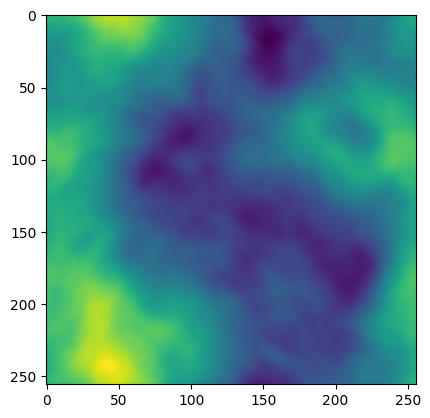

In [3]:
import matplotlib.pyplot as plt

plt.imshow(test_dataset["x"][0])

In [ ]:
import torch

data_test = torch.load(f'dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt',
                           weights_only=False)

FileNotFoundError: [Errno 2] No such file or directory: 'dim2d_nx256_N50_solver=exponax_nu0.000_t20.0_train_all_frames.pt'

In [ ]:
data_test

In [2]:
from pathlib import Path
import torch
import numpy as np

def summarize_pt(path):
    path = Path(path)
    data = torch.load(path, map_location="cpu", weights_only=False)
    print(f"[File] {path}")
    print(f"[Keys] {list(data.keys())}\n")

    def tensor_info(t: torch.Tensor):
        size_mb = t.element_size() * t.numel() / 1024**2
        msg = (f"Tensor | shape={tuple(t.shape)}, dtype={t.dtype}, device={t.device}, "
               f"numel={t.numel():,}, size≈{size_mb:.2f} MB")
        try:
            mn, mx, mean = t.min().item(), t.max().item(), t.mean().item()
            msg += f", min={mn:.6g}, max={mx:.6g}, mean={mean:.6g}"
        except Exception:
            pass
        return msg

    for k, v in data.items():
        if torch.is_tensor(v):
            info = tensor_info(v)
        elif isinstance(v, np.ndarray):
            info = f"ndarray | shape={v.shape}, dtype={v.dtype}"
        elif isinstance(v, (list, tuple)):
            info = f"{type(v).__name__} | len={len(v)}"
            if len(v) > 0:
                info += f", first_elem_type={type(v[0]).__name__}"
        elif isinstance(v, dict):
            info = f"dict | {len(v)} keys"
        else:
            info = f"{type(v).__name__}"
        print(f"- {k}: {info}")

    # 额外一致性检查（按你的数据格式约定）
    x = data.get("x", None)
    y = data.get("y", None)
    if torch.is_tensor(x):
        N, H, W = x.shape
        print(f"\n[Derived] N={N}, H={H}, W={W}")
    if torch.is_tensor(y) and y.ndim == 4:
        print(f"[Derived] y time-frames = {y.shape[-1]}")
        if torch.is_tensor(x) and (y.shape[:3] != x.shape):
            print("[Warn] x.shape != y.shape[:3]")

# 示例：
summarize_pt("dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt")


[File] dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt
[Keys] ['x', 'y', 'metadata']

- x: Tensor | shape=(1150, 256, 256), dtype=torch.float32, device=cpu, numel=75,366,400, size≈287.50 MB, min=-1.22778, max=1.28823, mean=-1.47787e-07
- y: Tensor | shape=(1150, 256, 256, 21), dtype=torch.float32, device=cpu, numel=1,582,694,400, size≈6037.50 MB, min=-4.7424e+12, max=2.65615e+12, mean=0.00264784
- metadata: dict | 7 keys

[Derived] N=1150, H=256, W=256
[Derived] y time-frames = 21


[File] dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt
[Bad index] 343 (max|y|=4.7424e+12)
x: shape=(256, 256), finite_ratio=1.000, min=-0.86437, max=0.646147, mean=-6.02566e-06
y@t=0: shape=(256, 256), finite_ratio=1.000, min=-0.86437, max=0.646147, mean=-6.02566e-06
y@t=19: shape=(256, 256), finite_ratio=1.000, min=-3.24817, max=3.1301, mean=-6.02379e-06


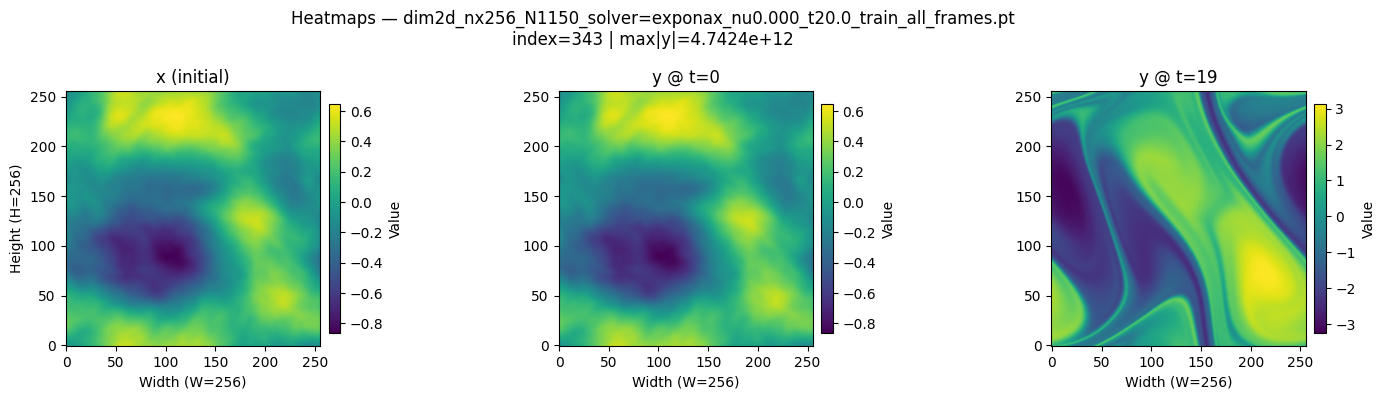

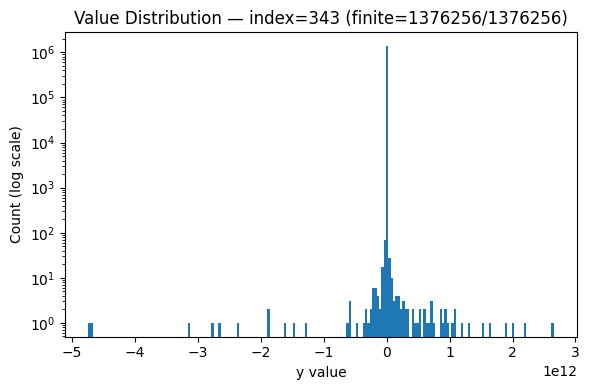

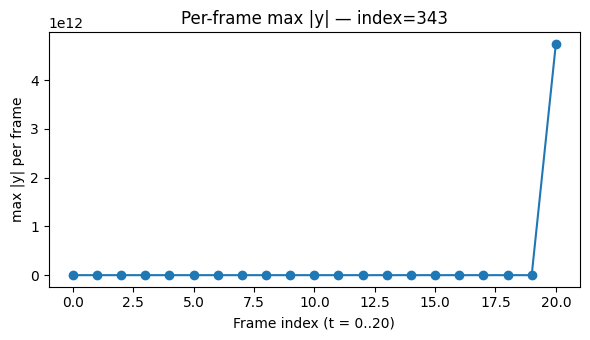

In [5]:
# Diagnose a bad sample in the dataset: heatmaps + value histogram (English labels)

from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- path & optional fixed index ---
pt_path = Path("dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt")
force_index = None  # e.g., set to an int to force a specific index; None -> auto find the worst

# --- load ---
data = torch.load(pt_path, map_location="cpu", weights_only=False)
x = data["x"]                # (N, H, W), float32
y = data["y"]                # (N, H, W, 21), float32

N, H, W = x.shape
assert y.shape[:3] == (N, H, W) and y.shape[-1] == 21

# --- find the "worst" sample by max |y| ---
y_absmax_per_sample = y.abs().amax(dim=(1, 2, 3))
bad_idx = int(y_absmax_per_sample.argmax()) if force_index is None else int(force_index)

xi  = x[bad_idx].numpy()                 # (H, W)
y0  = y[bad_idx, :, :, 0].numpy()        # (H, W)
y19 = y[bad_idx, :, :, 19].numpy()       # (H, W)

# --- quick stats ---
def stats(name, arr):
    arrf = arr[np.isfinite(arr)]
    print(f"{name}: shape={arr.shape}, finite_ratio={arrf.size/arr.size:.3f}, "
          f"min={np.nanmin(arr):.6g}, max={np.nanmax(arr):.6g}, mean={np.nanmean(arr):.6g}")

print(f"[File] {pt_path.name}")
print(f"[Bad index] {bad_idx} (max|y|={float(y_absmax_per_sample[bad_idx]):.6g})")
stats("x", xi); stats("y@t=0", y0); stats("y@t=19", y19)

# --- heatmaps (each with its own colorbar; use viridis; independent scales) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cmap = "viridis"

im0 = axes[0].imshow(xi, origin="lower", cmap=cmap)
axes[0].set_title("x (initial)")
axes[0].set_xlabel(f"Width (W={W})"); axes[0].set_ylabel(f"Height (H={H})")
fig.colorbar(im0, ax=axes[0], shrink=0.9, pad=0.02).set_label("Value")

im1 = axes[1].imshow(y0, origin="lower", cmap=cmap)
axes[1].set_title("y @ t=0")
axes[1].set_xlabel(f"Width (W={W})"); axes[1].set_ylabel("")
fig.colorbar(im1, ax=axes[1], shrink=0.9, pad=0.02).set_label("Value")

im2 = axes[2].imshow(y19, origin="lower", cmap=cmap)
axes[2].set_title("y @ t=19")
axes[2].set_xlabel(f"Width (W={W})"); axes[2].set_ylabel("")
fig.colorbar(im2, ax=axes[2], shrink=0.9, pad=0.02).set_label("Value")

supt = (f"Heatmaps — {pt_path.name}\n"
        f"index={bad_idx} | max|y|={float(y_absmax_per_sample[bad_idx]):.6g}")
fig.suptitle(supt, y=0.98)
plt.subplots_adjust(top=0.83)
plt.tight_layout()
plt.show()

# --- histogram to inspect distribution / outliers (log y-axis) ---
vals = y[bad_idx].detach().cpu().numpy().ravel()
finite = np.isfinite(vals)
plt.figure(figsize=(6,4))
plt.hist(vals[finite], bins=200, log=True)
plt.xlabel("y value"); plt.ylabel("Count (log scale)")
plt.title(f"Value Distribution — index={bad_idx} (finite={finite.sum()}/{vals.size})")
plt.tight_layout()
plt.show()

# --- (optional) per-frame max|y| curve to see when it explodes ---
frame_absmax = np.max(np.abs(y[bad_idx].numpy()), axis=(0,1))  # (21,)
plt.figure(figsize=(6,3.5))
plt.plot(np.arange(21), frame_absmax, marker='o')
plt.xlabel("Frame index (t = 0..20)")
plt.ylabel("max |y| per frame")
plt.title(f"Per-frame max |y| — index={bad_idx}")
plt.tight_layout()
plt.show()


[bad index] 343, worst frame t*=20, max|y|=4.7424e+12, at (i,j)=(91, 247)
y@t*: min=-4.7424e+12, max=2.65615e+12, mean=99.3842


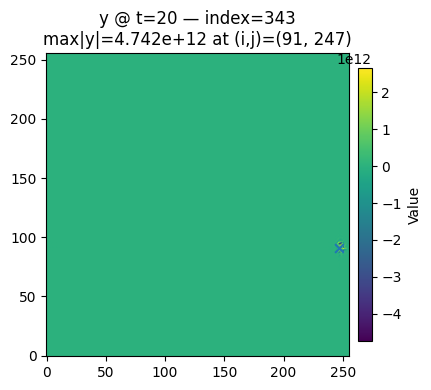

In [7]:
# Pinpoint which frame explodes, where it happens, and visualize it.
from pathlib import Path
import torch, numpy as np, matplotlib.pyplot as plt

pt_path = Path("dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt")
data = torch.load(pt_path, map_location="cpu", weights_only=False)
x, y = data["x"], data["y"]           # y: (N,H,W,21)

N,H,W = x.shape
bad_idx = 343  # 你看到的那条
assert y.shape[:3] == (N,H,W) and y.shape[-1] == 21

# 每一帧的 max|y|
frame_absmax = y[bad_idx].abs().amax(dim=(0,1))          # (21,)
t_star = int(frame_absmax.argmax())
Y = y[bad_idx, :, :, t_star]

# 极值与位置
val = float(Y.abs().amax())
ij = torch.nonzero(Y.abs()==Y.abs().amax(), as_tuple=False)[0].tolist()  # [i,j]
print(f"[bad index] {bad_idx}, worst frame t*={t_star}, max|y|={val:.6g}, at (i,j)={tuple(ij)}")

# 简要统计
def stats(name, arr):
    arr = arr.detach().cpu().numpy()
    print(f"{name}: min={arr.min():.6g}, max={arr.max():.6g}, mean={arr.mean():.6g}")
stats("y@t*", Y)

# 可视化该帧（各自独立色标，viridis）
plt.figure(figsize=(5,4))
im = plt.imshow(Y.detach().cpu().numpy(), origin="lower", cmap="viridis")
plt.scatter([ij[1]],[ij[0]], s=40, marker='x')  # 标出最大值位置
plt.title(f"y @ t={t_star} — index={bad_idx}\nmax|y|={val:.3e} at (i,j)={tuple(ij)}")
plt.colorbar(im, shrink=0.9, pad=0.02, label="Value")
plt.tight_layout(); plt.show()


In [8]:
import torch
data = torch.load("dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt", map_location="cpu", weights_only=False)
y = data["y"]  # (N,H,W,21)

thr = 1e6  # 你可以调，比如 1e8
# 每个样本每帧的最大绝对值
y_absmax = y.abs().amax(dim=(1,2))        # (N,21)
# 每一帧超过阈值的样本数
bad_count_per_frame = (y_absmax > thr).sum(dim=0)  # (21,)
print("bad_count_per_frame:", bad_count_per_frame.tolist())

bad_count_per_frame: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]


In [9]:
idx = 343
per_frame = y[idx].abs().amax(dim=(0,1))  # (21,)
print("per-frame max|y|:", [float(v) for v in per_frame])

per-frame max|y|: [0.8643696904182434, 0.9525609016418457, 1.0280917882919312, 1.1343082189559937, 1.2725112438201904, 1.405021071434021, 1.5303751230239868, 1.6496102809906006, 1.7712242603302002, 1.9020421504974365, 2.0402255058288574, 2.1759870052337646, 2.298335075378418, 2.41182017326355, 2.5412628650665283, 2.68235445022583, 2.809190273284912, 2.9413609504699707, 3.054351329803467, 3.248169183731079, 4742402539520.0]


In [10]:
from pathlib import Path
import torch
import numpy as np

def list_explosions(pt_path, k, check_x=True, check_y=True):
    """
    Print all (sample_idx, frame_idx) whose pixel abs value exceeds threshold k.
    For x (N,H,W): report any sample with max|x| > k.
    For y (N,H,W,21): report any (sample, frame) with max|y| > k.
    """
    pt_path = Path(pt_path)
    data = torch.load(pt_path, map_location="cpu", weights_only=False)
    print(f"[File] {pt_path}")
    if "x" not in data or "y" not in data:
        raise ValueError("dataset must contain keys 'x' and 'y'")

    x = data["x"]          # (N,H,W)
    y = data["y"]          # (N,H,W,21)
    N, H, W = x.shape
    assert y.shape[:3] == (N, H, W) and y.shape[-1] == 21, "y must be (N,H,W,21)"

    total_y_hits = 0
    total_x_hits = 0

    if check_y:
        # per (sample, frame) max|y|
        y_absmax = y.abs().amax(dim=(1,2))          # (N,21)
        mask = y_absmax > float(k)                  # (N,21) bool
        idx_pairs = torch.nonzero(mask, as_tuple=False).tolist()
        print(f"[Y] threshold k={k} -> {len(idx_pairs)} (sample,frame) hits")
        for i, t in idx_pairs:
            Y = y[i, :, :, t]
            Y_abs = Y.abs()
            max_abs = float(Y_abs.max())
            min_v  = float(Y.min())
            max_v  = float(Y.max())
            mean_v = float(Y.mean())
            cnt    = int((Y_abs > k).sum())
            # location of the max-abs (first occurrence)
            ij = torch.nonzero(Y_abs == Y_abs.max(), as_tuple=False)[0].tolist()
            print(f"  - sample={i:4d}, frame={t:2d} | "
                  f"max|y|={max_abs:.6g} at (i,j)={tuple(ij)} | "
                  f"min={min_v:.6g}, max={max_v:.6g}, mean={mean_v:.6g}, "
                  f"count(|y|>k)={cnt}")
        total_y_hits = len(idx_pairs)

    if check_x:
        # per sample max|x|
        x_absmax = x.abs().amax(dim=(1,2))          # (N,)
        maskx = x_absmax > float(k)                 # (N,) bool
        idx_list = torch.nonzero(maskx, as_tuple=False).flatten().tolist()
        print(f"[X] threshold k={k} -> {len(idx_list)} sample hits")
        for i in idx_list:
            Xi = x[i]
            Xi_abs = Xi.abs()
            max_abs = float(Xi_abs.max())
            min_v  = float(Xi.min())
            max_v  = float(Xi.max())
            mean_v = float(Xi.mean())
            cnt    = int((Xi_abs > k).sum())
            ij = torch.nonzero(Xi_abs == Xi_abs.max(), as_tuple=False)[0].tolist()
            print(f"  - sample={i:4d} | "
                  f"max|x|={max_abs:.6g} at (i,j)={tuple(ij)} | "
                  f"min={min_v:.6g}, max={max_v:.6g}, mean={mean_v:.6g}, "
                  f"count(|x|>k)={cnt}")
        total_x_hits = len(idx_list)

    print(f"\n[Summary] y-hits={total_y_hits}, x-hits={total_x_hits}, threshold k={k}")

# 用法示例：
list_explosions("dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt", k=1e1)

[File] dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt
[Y] threshold k=10.0 -> 49 (sample,frame) hits
  - sample=  10, frame=20 | max|y|=28.6557 at (i,j)=(64, 48) | min=-28.6557, max=28.0391, mean=-4.00096e-06, count(|y|>k)=283
  - sample=  19, frame=20 | max|y|=149.207 at (i,j)=(33, 200) | min=-149.207, max=142.564, mean=-4.60446e-06, count(|y|>k)=1347
  - sample=  20, frame=20 | max|y|=986.198 at (i,j)=(194, 38) | min=-884.449, max=986.198, mean=1.56462e-06, count(|y|>k)=3056
  - sample=  40, frame=20 | max|y|=11.4499 at (i,j)=(3, 100) | min=-11.4499, max=11.3291, mean=2.32458e-06, count(|y|>k)=21
  - sample=  41, frame=20 | max|y|=12.8663 at (i,j)=(54, 28) | min=-12.4804, max=12.8663, mean=2.87592e-06, count(|y|>k)=46
  - sample=  57, frame=20 | max|y|=436.567 at (i,j)=(110, 249) | min=-431.646, max=436.567, mean=2.68221e-06, count(|y|>k)=2291
  - sample=  58, frame=20 | max|y|=139.842 at (i,j)=(204, 136) | min=-137.621, max=139.842, mean=-2.72691e-06, count(|y|>k

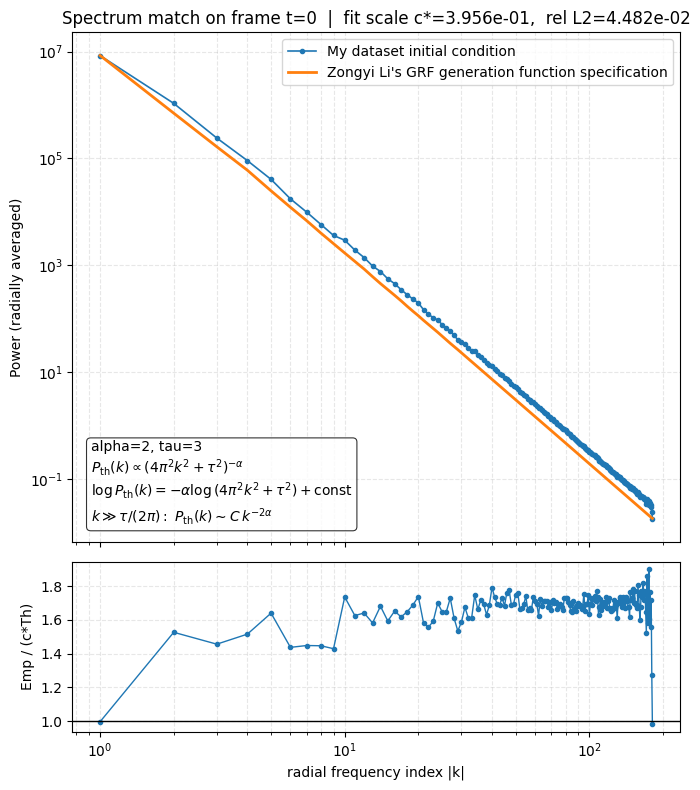

In [1]:
# %% imports
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt

# ========== 工具：构造与 GRF 一致的 k-网格、径向分箱索引 ==========
def _kgrid_and_bins(size: int, device="cpu"):
    """
    返回:
      kx, ky: (H,W) 整数波数网格 (未shift)
      ri_flat: (H*W,) 每个像元所在的整数半径分箱索引 floor(||k||)
      counts: (Rmax+1,) 每个半径分箱像元数量（单张平面）
    """
    H = W = size
    kmax = size // 2
    k1d = torch.cat((torch.arange(0, kmax, device=device),
                     torch.arange(-kmax, 0, device=device)), 0)
    kx = k1d.view(1, -1).repeat(H, 1)
    ky = k1d.view(-1, 1).repeat(1, W)

    r = torch.sqrt(kx.to(torch.float32)**2 + ky.to(torch.float32)**2)
    ri = torch.floor(r).to(torch.int64)                # 整数半径桶
    ri_flat = ri.reshape(-1)
    Rmax = int(ri_flat.max().item())
    counts = torch.bincount(ri_flat, minlength=Rmax+1).to(torch.float64)
    return kx, ky, ri_flat, counts

# ========== 经验功率谱（角向平均） ==========
@torch.no_grad()
def empirical_radial_psd_from_y0(y0: torch.Tensor, batch_size=64, device="cpu", fft_norm="backward"):
    """
    y0: (N, H, W)  第0帧的张量（float）
    返回:
      freq_k: (R,)  非负整数半径 k
      P_emp : (R,)  经验角向平均功率谱（已对像元计数与样本数做平均）
    """
    assert y0.ndim == 3, f"expect (N,H,W), got {tuple(y0.shape)}"
    N, H, W = map(int, y0.shape)
    assert H == W, "仅处理方阵"
    device = torch.device(device)

    # 预计算分箱
    _, _, ri_flat, counts_grid = _kgrid_and_bins(H, device=device)
    R = counts_grid.numel()
    sums = torch.zeros(R, dtype=torch.float64, device=device)

    # 批处理累加
    left = N
    idx = 0
    while left > 0:
        b = min(batch_size, left)
        x = y0[idx:idx+b].to(device, non_blocking=True)            # (b,H,W)
        x = x - x.mean(dim=(-2,-1), keepdim=True)                  # 去 DC
        F = torch.fft.fft2(x, norm=fft_norm)                       # (b,H,W)
        P = (F.real**2 + F.imag**2).to(torch.float64)              # 功率

        # 把 b 个样本摊平成一条长向量做一次 scatter_add
        P_flat = P.reshape(-1)                                      # b*H*W
        ri_rep = ri_flat.repeat(b)                                  # b*H*W
        sums.scatter_add_(0, ri_rep, P_flat)
        idx += b
        left -= b

    # 对像元数与样本数取平均
    P_emp = sums / (counts_grid * N + 1e-12)
    freq_k = torch.arange(R, device=device)
    return freq_k.cpu().numpy(), P_emp.cpu().numpy()

# ========== 解析功率谱（由 GRF 的 sqrt_eig^2 得到） ==========
def analytic_radial_psd(size: int, alpha=2.0, tau=3.0, sigma=None, device="cpu"):
    """
    返回:
      freq_k: (R,), P_grf: (R,) —— 未做缩放拟合的“形状”曲线
    """
    device = torch.device(device)
    kx, ky, ri_flat, counts = _kgrid_and_bins(size, device=device)
    if sigma is None:
        sigma = tau**(0.5*(2*alpha - 2))  # dim=2

    # 与你类里一致的 sqrt_eig（dim=2）
    # 注意：这里只关心形状 -> 最后会做一档缩放拟合
    sqrt_eig = (size**2) * (np.sqrt(2.0)) * sigma * \
        (4*(np.pi**2)*(kx**2 + ky**2) + (tau**2))**(-alpha/2.0)
    sqrt_eig[0,0] = 0.0

    P_full = (sqrt_eig**2).to(torch.float64).reshape(-1)  # (H*W,)
    R = counts.numel()
    sums = torch.zeros(R, dtype=torch.float64, device=device)
    sums.scatter_add_(0, ri_flat, P_full)
    P_grf = (sums / (counts + 1e-12)).cpu().numpy()
    freq_k = torch.arange(R).cpu().numpy()
    return freq_k, P_grf
def compare_dataset_with_grf_spectrum(
    pt_path,
    alpha=2.0, tau=3.0, sigma=None,
    max_samples=None, batch_size=64, device="cpu",
    kmin=1, kmax=None, fft_norm="backward",
    label=None
):
    """
    读取 pt -> 取 y[...,0] -> 经验谱 vs 解析谱（做一档缩放）并画图。
    """
    pt_path = Path(pt_path)
    payload = torch.load(pt_path, map_location="cpu", weights_only=False)
    assert isinstance(payload, dict) and "y" in payload, f"{pt_path.name}: missing 'y'"
    y = payload["y"]
    assert torch.is_tensor(y) and y.ndim == 4, f"{pt_path.name}: y should be (N,H,W,T)"
    if y.dtype not in (torch.float32, torch.float64):
        y = y.float()

    N, H, W, T = map(int, y.shape)
    if max_samples is not None and max_samples < N:
        N_use = int(max_samples)
        y0 = y[:N_use, :, :, 0].contiguous()
    else:
        N_use = N
        y0 = y[:, :, :, 0].contiguous()

    # 经验谱（角向平均）
    k_emp, P_emp = empirical_radial_psd_from_y0(
        y0, batch_size=batch_size, device=device, fft_norm=fft_norm
    )

    # 解析谱（由 sqrt_eig^2 的角向平均）
    k_th,  P_th_raw = analytic_radial_psd(
        H, alpha=alpha, tau=tau, sigma=sigma, device=device
    )
    if kmax is None:
        kmax = min(k_emp[-1], k_th[-1])

    # 对指定频段做“一档缩放”拟合
    m = (k_emp >= kmin) & (k_emp <= kmax)
    Pe = torch.from_numpy(P_emp[m]).to(torch.float64)
    Pt = torch.from_numpy(P_th_raw[m]).to(torch.float64)
    c_star = (Pe @ Pt) / (Pt @ Pt + 1e-12)
    P_th = (c_star.item() * P_th_raw)

    # 简单一致性指标（拟合段相对 L2 误差）
    rel_l2 = torch.linalg.norm(Pe - c_star*Pt) / (torch.linalg.norm(Pe) + 1e-12)

    # ----- 画图：loglog + 比值，并按你的需求自定义 legend -----
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(7, 8), sharex=True, gridspec_kw={"height_ratios":[3,1]}
    )

    emp_label = "My dataset initial condition"
    th_label  = "Zongyi Li's GRF generation function specification"

    ax1.loglog(k_emp[m], P_emp[m], 'o-', ms=3, lw=1.2, label=emp_label)
    ax1.loglog(k_th[m],  P_th [m],  '-',  lw=2.0, label=th_label)

    ax1.set_ylabel("Power (radially averaged)")
    ax1.grid(True, which='both', ls='--', alpha=0.3)
    ax1.legend(loc='best')

    ax1.set_title(
        f"Spectrum match on frame t=0  |  fit scale c*={c_star.item():.3e},  rel L2={rel_l2.item():.3e}"
    )

    # —— 在图上标注理论公式与 log–log 形式（mathtext 兼容版）——
    # P_th(k) ∝ (4π^2 k^2 + τ^2)^(-α)
    # log P_th(k) = -α log(4π^2 k^2 + τ^2) + const
    # k >> τ/(2π): P_th(k) ~ C k^{-2α}
    eq1 = r"$P_{\mathrm{th}}(k)\propto\left(4\pi^{2}k^{2}+\tau^{2}\right)^{-\alpha}$"
    eq2 = r"$\log P_{\mathrm{th}}(k)=-\alpha\log\left(4\pi^{2}k^{2}+\tau^{2}\right)+\mathrm{const}$"
    eq3 = r"$k\gg\tau/(2\pi):\ P_{\mathrm{th}}(k)\sim C\,k^{-2\alpha}$"
    param_str = f"alpha={alpha:.3g}, tau={tau:.3g}"

    txt = param_str + "\n" + eq1 + "\n" + eq2 + "\n" + eq3
    ax1.text(
        0.03, 0.03, txt,
        transform=ax1.transAxes, ha='left', va='bottom', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, lw=0.8)
    )

    # 比值图
    ratio = (P_emp[m] / (P_th[m] + 1e-30))
    ax2.semilogx(k_emp[m], ratio, 'o-', ms=3, lw=1.0)
    ax2.axhline(1.0, color='k', lw=1)
    ax2.set_xlabel("radial frequency index |k|")
    ax2.set_ylabel("Emp / (c*Th)")
    ax2.grid(True, which='both', ls='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        "k": k_emp,
        "P_emp": P_emp,
        "P_th_raw": P_th_raw,
        "P_th_scaled": P_th,
        "scale_c": float(c_star.item()),
        "rel_L2": float(rel_l2.item()),
        "N_used": N_use,
        "size": H,
    }


# ================= 示例调用 =================
# 把路径换成你的文件；alpha/tau 用你期望验证的 GRF 参数
# 你可以跑两次：train / test 各画一张图
res_train = compare_dataset_with_grf_spectrum(
    pt_path="generalizability/dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_test_ntimepoints21_GRF_matern_alpha2_tau3_vmax0.4_vmin-0.4_batch0_all_frames.pt",
    alpha=2.0, tau=3.0, sigma=None,
    max_samples=None,        # 用全部样本；如需加速可设为 400 等
    batch_size=64,
    device="cpu",            # 如需 GPU 改成 "cuda"
    kmin=1, kmax=None,
    fft_norm="backward",
    label="train"
)

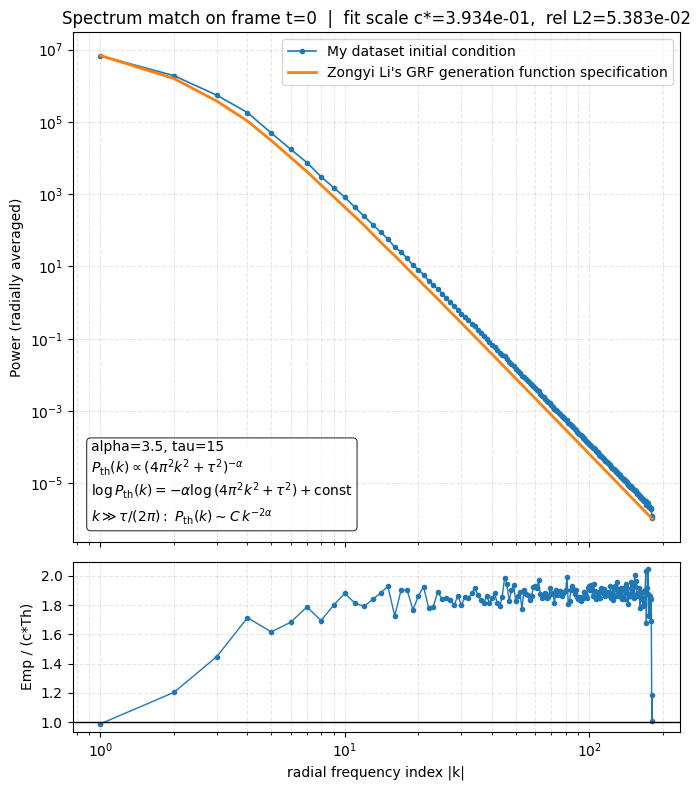

In [15]:
# %% imports
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt

# ========== 工具：构造与 GRF 一致的 k-网格、径向分箱索引 ==========
def _kgrid_and_bins(size: int, device="cpu"):
    """
    返回:
      kx, ky: (H,W) 整数波数网格 (未shift)
      ri_flat: (H*W,) 每个像元所在的整数半径分箱索引 floor(||k||)
      counts: (Rmax+1,) 每个半径分箱像元数量（单张平面）
    """
    H = W = size
    kmax = size // 2
    k1d = torch.cat((torch.arange(0, kmax, device=device),
                     torch.arange(-kmax, 0, device=device)), 0)
    kx = k1d.view(1, -1).repeat(H, 1)
    ky = k1d.view(-1, 1).repeat(1, W)

    r = torch.sqrt(kx.to(torch.float32)**2 + ky.to(torch.float32)**2)
    ri = torch.floor(r).to(torch.int64)                # 整数半径桶
    ri_flat = ri.reshape(-1)
    Rmax = int(ri_flat.max().item())
    counts = torch.bincount(ri_flat, minlength=Rmax+1).to(torch.float64)
    return kx, ky, ri_flat, counts

# ========== 经验功率谱（角向平均） ==========
@torch.no_grad()
def empirical_radial_psd_from_y0(y0: torch.Tensor, batch_size=64, device="cpu", fft_norm="backward"):
    """
    y0: (N, H, W)  第0帧的张量（float）
    返回:
      freq_k: (R,)  非负整数半径 k
      P_emp : (R,)  经验角向平均功率谱（已对像元计数与样本数做平均）
    """
    assert y0.ndim == 3, f"expect (N,H,W), got {tuple(y0.shape)}"
    N, H, W = map(int, y0.shape)
    assert H == W, "仅处理方阵"
    device = torch.device(device)

    # 预计算分箱
    _, _, ri_flat, counts_grid = _kgrid_and_bins(H, device=device)
    R = counts_grid.numel()
    sums = torch.zeros(R, dtype=torch.float64, device=device)

    # 批处理累加
    left = N
    idx = 0
    while left > 0:
        b = min(batch_size, left)
        x = y0[idx:idx+b].to(device, non_blocking=True)            # (b,H,W)
        x = x - x.mean(dim=(-2,-1), keepdim=True)                  # 去 DC
        F = torch.fft.fft2(x, norm=fft_norm)                       # (b,H,W)
        P = (F.real**2 + F.imag**2).to(torch.float64)              # 功率

        # 把 b 个样本摊平成一条长向量做一次 scatter_add
        P_flat = P.reshape(-1)                                      # b*H*W
        ri_rep = ri_flat.repeat(b)                                  # b*H*W
        sums.scatter_add_(0, ri_rep, P_flat)
        idx += b
        left -= b

    # 对像元数与样本数取平均
    P_emp = sums / (counts_grid * N + 1e-12)
    freq_k = torch.arange(R, device=device)
    return freq_k.cpu().numpy(), P_emp.cpu().numpy()

# ========== 解析功率谱（由 GRF 的 sqrt_eig^2 得到） ==========
def analytic_radial_psd(size: int, alpha=2.0, tau=3.0, sigma=None, device="cpu"):
    """
    返回:
      freq_k: (R,), P_grf: (R,) —— 未做缩放拟合的“形状”曲线
    """
    device = torch.device(device)
    kx, ky, ri_flat, counts = _kgrid_and_bins(size, device=device)
    if sigma is None:
        sigma = tau**(0.5*(2*alpha - 2))  # dim=2

    # 与你类里一致的 sqrt_eig（dim=2）
    # 注意：这里只关心形状 -> 最后会做一档缩放拟合
    sqrt_eig = (size**2) * (np.sqrt(2.0)) * sigma * \
        (4*(np.pi**2)*(kx**2 + ky**2) + (tau**2))**(-alpha/2.0)
    sqrt_eig[0,0] = 0.0

    P_full = (sqrt_eig**2).to(torch.float64).reshape(-1)  # (H*W,)
    R = counts.numel()
    sums = torch.zeros(R, dtype=torch.float64, device=device)
    sums.scatter_add_(0, ri_flat, P_full)
    P_grf = (sums / (counts + 1e-12)).cpu().numpy()
    freq_k = torch.arange(R).cpu().numpy()
    return freq_k, P_grf
def compare_dataset_with_grf_spectrum(
    pt_path,
    alpha=2.0, tau=3.0, sigma=None,
    max_samples=None, batch_size=64, device="cpu",
    kmin=1, kmax=None, fft_norm="backward",
    label=None
):
    """
    读取 pt -> 取 y[...,0] -> 经验谱 vs 解析谱（做一档缩放）并画图。
    """
    pt_path = Path(pt_path)
    payload = torch.load(pt_path, map_location="cpu", weights_only=False)
    assert isinstance(payload, dict) and "y" in payload, f"{pt_path.name}: missing 'y'"
    y = payload["y"]
    assert torch.is_tensor(y) and y.ndim == 4, f"{pt_path.name}: y should be (N,H,W,T)"
    if y.dtype not in (torch.float32, torch.float64):
        y = y.float()

    N, H, W, T = map(int, y.shape)
    if max_samples is not None and max_samples < N:
        N_use = int(max_samples)
        y0 = y[:N_use, :, :, 0].contiguous()
    else:
        N_use = N
        y0 = y[:, :, :, 0].contiguous()

    # 经验谱（角向平均）
    k_emp, P_emp = empirical_radial_psd_from_y0(
        y0, batch_size=batch_size, device=device, fft_norm=fft_norm
    )

    # 解析谱（由 sqrt_eig^2 的角向平均）
    k_th,  P_th_raw = analytic_radial_psd(
        H, alpha=alpha, tau=tau, sigma=sigma, device=device
    )
    if kmax is None:
        kmax = min(k_emp[-1], k_th[-1])

    # 对指定频段做“一档缩放”拟合
    m = (k_emp >= kmin) & (k_emp <= kmax)
    Pe = torch.from_numpy(P_emp[m]).to(torch.float64)
    Pt = torch.from_numpy(P_th_raw[m]).to(torch.float64)
    c_star = (Pe @ Pt) / (Pt @ Pt + 1e-12)
    P_th = (c_star.item() * P_th_raw)

    # 简单一致性指标（拟合段相对 L2 误差）
    rel_l2 = torch.linalg.norm(Pe - c_star*Pt) / (torch.linalg.norm(Pe) + 1e-12)

    # ----- 画图：loglog + 比值，并按你的需求自定义 legend -----
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(7, 8), sharex=True, gridspec_kw={"height_ratios":[3,1]}
    )

    emp_label = "My dataset initial condition"
    th_label  = "Zongyi Li's GRF generation function specification"

    ax1.loglog(k_emp[m], P_emp[m], 'o-', ms=3, lw=1.2, label=emp_label)
    ax1.loglog(k_th[m],  P_th [m],  '-',  lw=2.0, label=th_label)

    ax1.set_ylabel("Power (radially averaged)")
    ax1.grid(True, which='both', ls='--', alpha=0.3)
    ax1.legend(loc='best')

    ax1.set_title(
        f"Spectrum match on frame t=0  |  fit scale c*={c_star.item():.3e},  rel L2={rel_l2.item():.3e}"
    )

    # —— 在图上标注理论公式与 log–log 形式（mathtext 兼容版）——
    # P_th(k) ∝ (4π^2 k^2 + τ^2)^(-α)
    # log P_th(k) = -α log(4π^2 k^2 + τ^2) + const
    # k >> τ/(2π): P_th(k) ~ C k^{-2α}
    eq1 = r"$P_{\mathrm{th}}(k)\propto\left(4\pi^{2}k^{2}+\tau^{2}\right)^{-\alpha}$"
    eq2 = r"$\log P_{\mathrm{th}}(k)=-\alpha\log\left(4\pi^{2}k^{2}+\tau^{2}\right)+\mathrm{const}$"
    eq3 = r"$k\gg\tau/(2\pi):\ P_{\mathrm{th}}(k)\sim C\,k^{-2\alpha}$"
    param_str = f"alpha={alpha:.3g}, tau={tau:.3g}"

    txt = param_str + "\n" + eq1 + "\n" + eq2 + "\n" + eq3
    ax1.text(
        0.03, 0.03, txt,
        transform=ax1.transAxes, ha='left', va='bottom', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, lw=0.8)
    )

    # 比值图
    ratio = (P_emp[m] / (P_th[m] + 1e-30))
    ax2.semilogx(k_emp[m], ratio, 'o-', ms=3, lw=1.0)
    ax2.axhline(1.0, color='k', lw=1)
    ax2.set_xlabel("radial frequency index |k|")
    ax2.set_ylabel("Emp / (c*Th)")
    ax2.grid(True, which='both', ls='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        "k": k_emp,
        "P_emp": P_emp,
        "P_th_raw": P_th_raw,
        "P_th_scaled": P_th,
        "scale_c": float(c_star.item()),
        "rel_L2": float(rel_l2.item()),
        "N_used": N_use,
        "size": H,
    }


# ================= 示例调用 =================
# 把路径换成你的文件；alpha/tau 用你期望验证的 GRF 参数
# 你可以跑两次：train / test 各画一张图
res_train = compare_dataset_with_grf_spectrum(
    pt_path="generalizability/dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_test_ntimepoints21_GRF_matern_alpha3.500_tau15_vmax0.4_vmin-0.4_batch0_all_frames.pt",
    alpha=3.5, tau=15, sigma=None,
    max_samples=None,        # 用全部样本；如需加速可设为 400 等
    batch_size=64,
    device="cpu",            # 如需 GPU 改成 "cuda"
    kmin=1, kmax=None,
    fft_norm="backward",
    label="train"
)

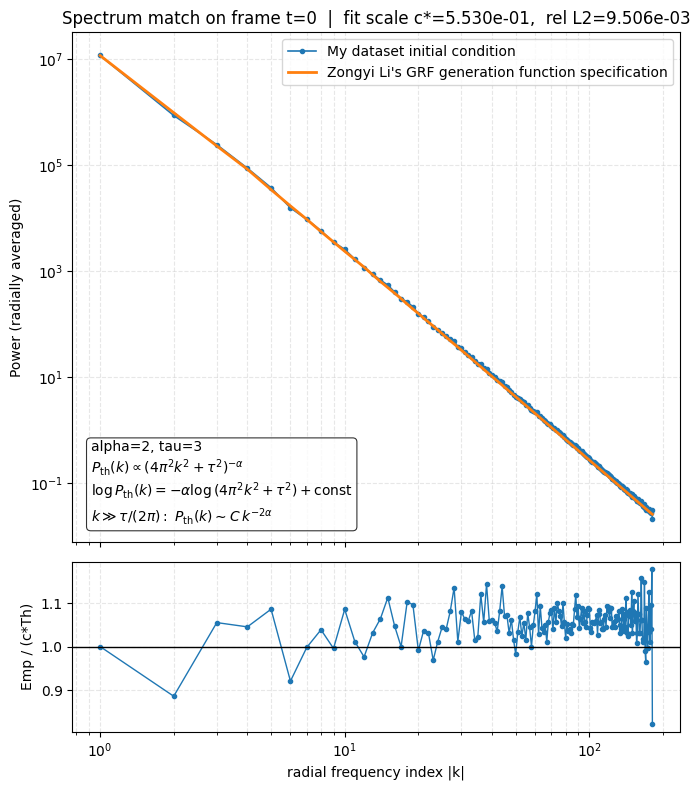

In [8]:
res_train = compare_dataset_with_grf_spectrum(
    pt_path="generalizability/dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_test_ntimepoints21_GRF_matern_alpha2_tau1_vmax0.4_vmin-0.4_batch0_all_frames.pt",
    alpha=2.0, tau=3.0, sigma=None,
    max_samples=None,        # 用全部样本；如需加速可设为 400 等
    batch_size=64,
    device="cpu",            # 如需 GPU 改成 "cuda"
    kmin=1, kmax=None,
    fft_norm="backward",
    label="train"
)

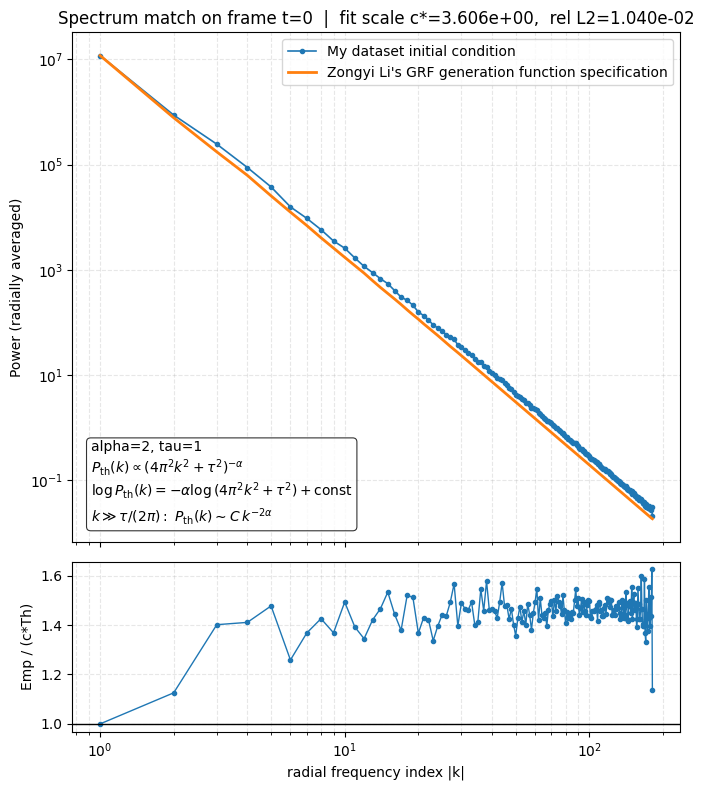

In [9]:
res_train = compare_dataset_with_grf_spectrum(
    pt_path="generalizability/dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_test_ntimepoints21_GRF_matern_alpha2_tau1_vmax0.4_vmin-0.4_batch0_all_frames.pt",
    alpha=2.0, tau=1.0, sigma=None,
    max_samples=None,        # 用全部样本；如需加速可设为 400 等
    batch_size=64,
    device="cpu",            # 如需 GPU 改成 "cuda"
    kmin=1, kmax=None,
    fft_norm="backward",
    label="train"
)

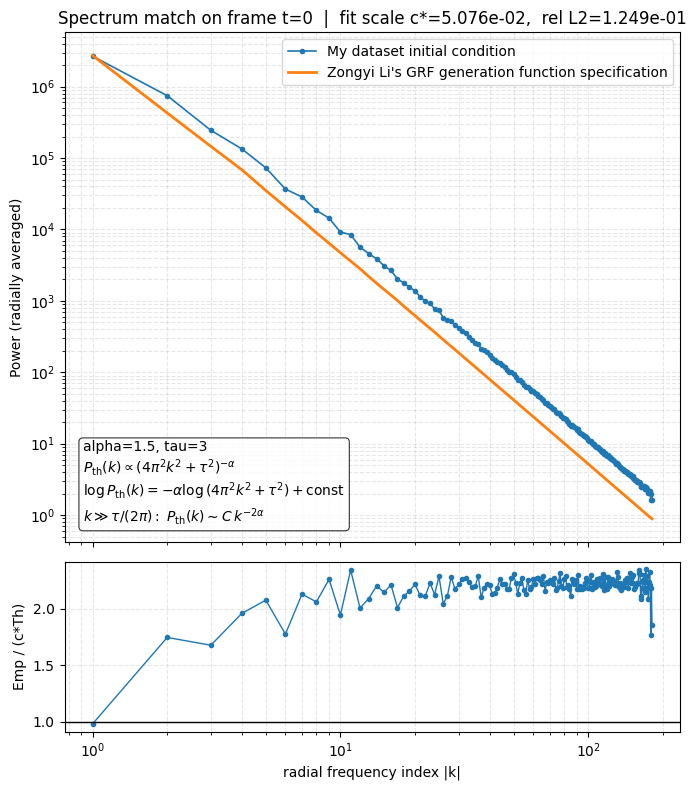

In [10]:
res_train = compare_dataset_with_grf_spectrum(
    pt_path="generalizability/dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_test_ntimepoints21_GRF_matern_alpha1.500_tau3_vmax0.4_vmin-0.4_batch0_all_frames.pt",
    alpha=1.5, tau=3.0, sigma=None,
    max_samples=None,        # 用全部样本；如需加速可设为 400 等
    batch_size=64,
    device="cpu",            # 如需 GPU 改成 "cuda"
    kmin=1, kmax=None,
    fft_norm="backward",
    label="train"
)

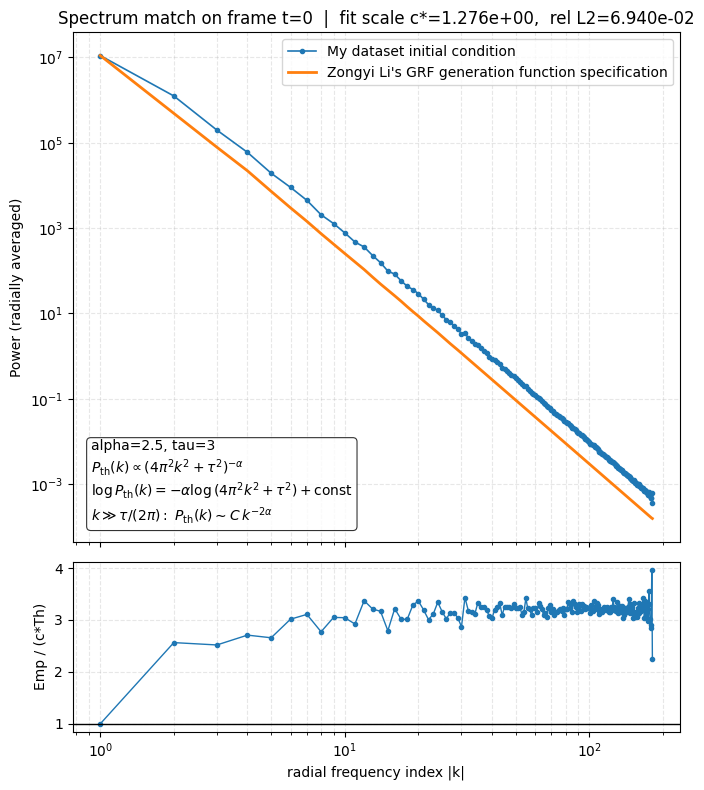

In [11]:
res_train = compare_dataset_with_grf_spectrum(
    pt_path="generalizability/dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_test_ntimepoints21_GRF_matern_alpha2.500_tau3_vmax0.4_vmin-0.4_batch0_all_frames.pt",
    alpha=2.5, tau=3.0, sigma=None,
    max_samples=None,        # 用全部样本；如需加速可设为 400 等
    batch_size=64,
    device="cpu",            # 如需 GPU 改成 "cuda"
    kmin=1, kmax=None,
    fft_norm="backward",
    label="train"
)

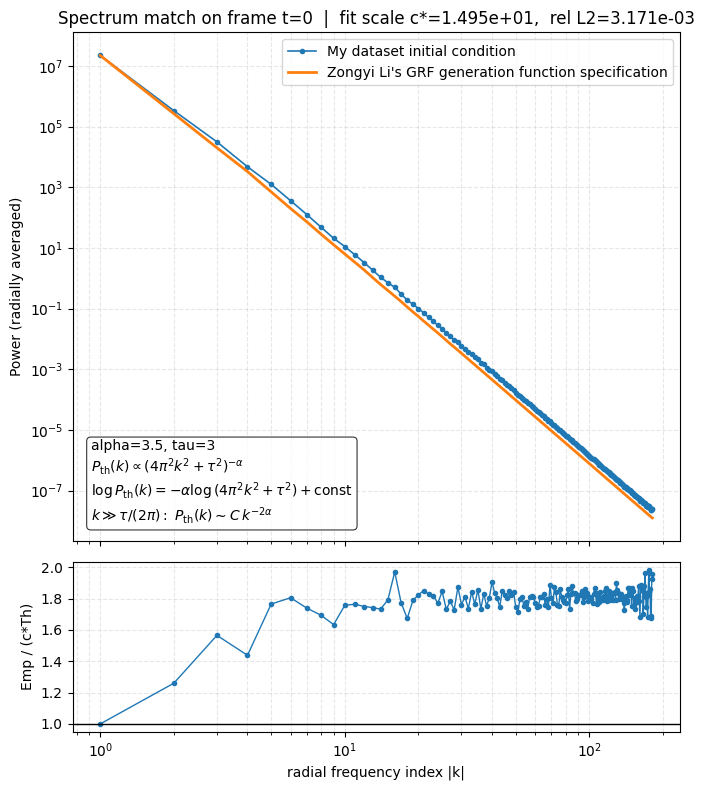

In [12]:
res_train = compare_dataset_with_grf_spectrum(
    pt_path="generalizability/dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_test_ntimepoints21_GRF_matern_alpha3.500_tau3_vmax0.4_vmin-0.4_batch0_all_frames.pt",
    alpha=3.5, tau=3.0, sigma=None,
    max_samples=None,        # 用全部样本；如需加速可设为 400 等
    batch_size=64,
    device="cpu",            # 如需 GPU 改成 "cuda"
    kmin=1, kmax=None,
    fft_norm="backward",
    label="train"
)

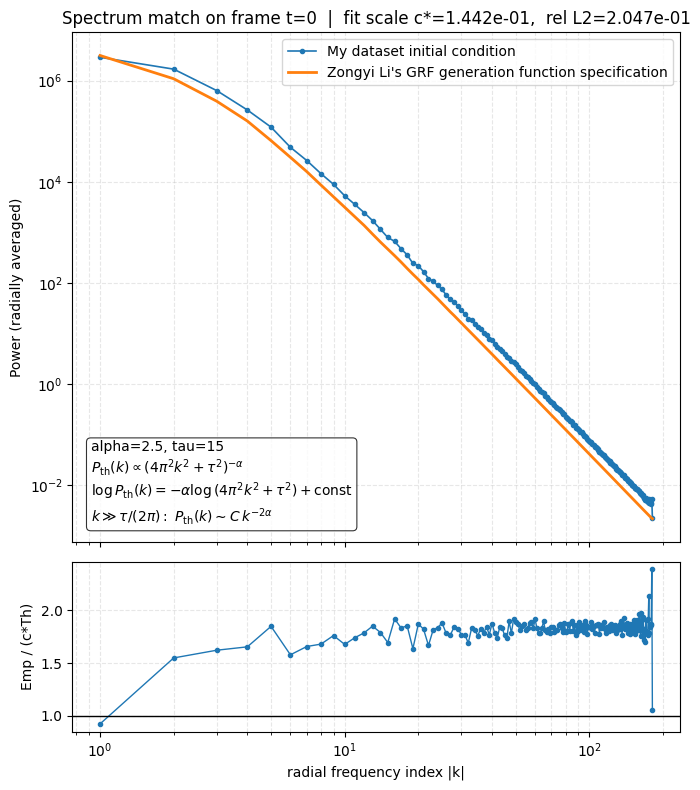

In [13]:
res_train = compare_dataset_with_grf_spectrum(
    pt_path="generalizability/dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_test_ntimepoints21_GRF_matern_alpha2.500_tau15_vmax0.4_vmin-0.4_batch0_all_frames.pt",
    alpha=2.5, tau=15, sigma=None,
    max_samples=None,        # 用全部样本；如需加速可设为 400 等
    batch_size=64,
    device="cpu",            # 如需 GPU 改成 "cuda"
    kmin=1, kmax=None,
    fft_norm="backward",
    label="train"
)

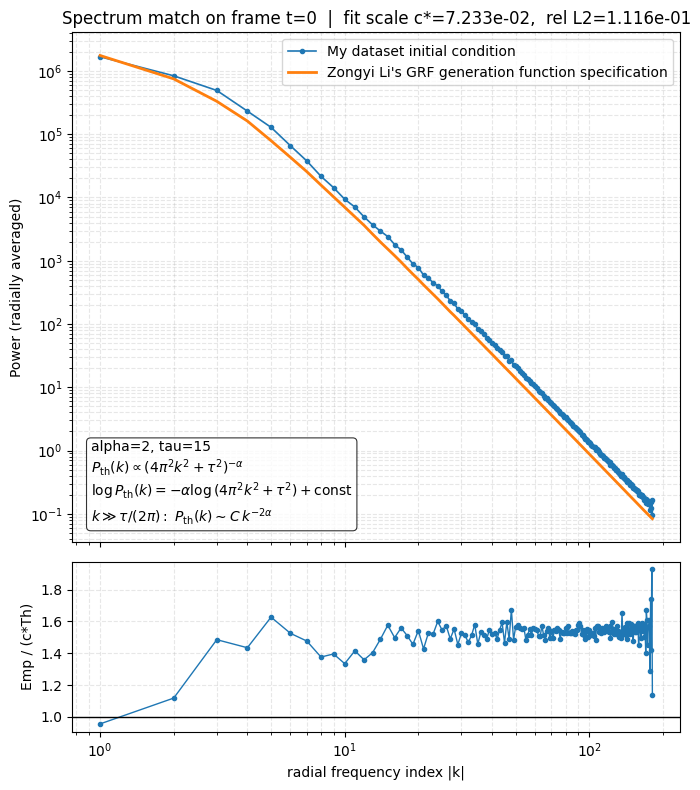

In [14]:
res_train = compare_dataset_with_grf_spectrum(
    pt_path="generalizability/dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_test_ntimepoints21_GRF_matern_alpha2_tau15_vmax0.4_vmin-0.4_batch0_all_frames.pt",
    alpha=2.0, tau=15, sigma=None,
    max_samples=None,        # 用全部样本；如需加速可设为 400 等
    batch_size=64,
    device="cpu",            # 如需 GPU 改成 "cuda"
    kmin=1, kmax=None,
    fft_norm="backward",
    label="train"
)